<a href="https://colab.research.google.com/github/shivainlabs/Machine-Learning/blob/main/Supervised%20Learning/Linear%20Regression/Different_loss_and_optimization_technique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day48-simple-linear-regression/placement.csv"

df = pd.read_csv(url)

In [18]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [19]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn.linear_model import QuantileRegressor
from sklearn.linear_model import SGDRegressor

Loss: MSE, Optimization: Least-squares solver

In [21]:
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print("MAE",mean_absolute_error(y_test,lr_pred))
print("MSE",mean_squared_error(y_test,lr_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,lr_pred)))
print("R2",r2_score(y_test,lr_pred))

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 0.780730147510384


Loss: HuberLoss, Optimization: Iterative numerical optimization

In [22]:
hb = HuberRegressor()
hb.fit(X_train,y_train)
hb_pred = hb.predict(X_test)

print("MAE",mean_absolute_error(y_test,hb_pred))
print("MSE",mean_squared_error(y_test,hb_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,hb_pred)))
print("R2",r2_score(y_test,hb_pred))

MAE 0.28713279188782265
MSE 0.12031675914772999
RMSE 0.3468670626446535
R2 0.782493806505693


Loss: MAE/ quantile objective, Optimization: Numerical optimization

In [23]:
qr = QuantileRegressor(quantile=0.5,alpha=0)
qr.fit(X_train,y_train)
qr_pred = qr.predict(X_test)

print("MAE",mean_absolute_error(y_test,qr_pred))
print("MSE",mean_squared_error(y_test,qr_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,qr_pred)))
print("R2",r2_score(y_test,qr_pred))

MAE 0.28728571428571426
MSE 0.12024887755102039
RMSE 0.346769199253654
R2 0.7826165214775157


Loss: MSE, Optimization: SGD

In [24]:
sgd_sq = SGDRegressor(loss="squared_error",random_state=42)
sgd_sq.fit(X_train, y_train)
sgd_sq_pred = sgd_sq.predict(X_test)

print("MAE",mean_absolute_error(y_test,sgd_sq_pred))
print("MSE",mean_squared_error(y_test,sgd_sq_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,sgd_sq_pred)))
print("R2",r2_score(y_test,sgd_sq_pred))

MAE 0.3301364262249746
MSE 0.15568358511154368
RMSE 0.3945675925764097
R2 0.7185583768460595


Loss: Huber, Optimization: SGD

In [25]:
sgd_hb = SGDRegressor(loss="huber",random_state=42)
sgd_hb.fit(X_train, y_train)
sgd_hb_pred = sgd_hb.predict(X_test)

print("MAE",mean_absolute_error(y_test,sgd_hb_pred))
print("MSE",mean_squared_error(y_test,sgd_hb_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,sgd_hb_pred)))
print("R2",r2_score(y_test,sgd_hb_pred))

MAE 0.3338986362621891
MSE 0.16031172618302958
RMSE 0.40038946812201437
R2 0.7101917174168644


## Controlled Experiment

Same Model + Same Loss --> Why are the results slightly different?

In [26]:
print("="*50,"\nLinear Regression\n")

lr = LinearRegression()
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print("MAE",mean_absolute_error(y_test,lr_pred))
print("MSE",mean_squared_error(y_test,lr_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,lr_pred)))
print("R2",r2_score(y_test,lr_pred))

print("="*50,"\nSGD Squared Loss\n")

sgd_sq = SGDRegressor(loss="squared_error",random_state=42)
sgd_sq.fit(X_train, y_train)
sgd_sq_pred = sgd_sq.predict(X_test)

print("MAE",mean_absolute_error(y_test,sgd_sq_pred))
print("MSE",mean_squared_error(y_test,sgd_sq_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,sgd_sq_pred)))
print("R2",r2_score(y_test,sgd_sq_pred))

print("="*50)

Linear Regression

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 0.780730147510384
SGD Squared Loss

MAE 0.3301364262249746
MSE 0.15568358511154368
RMSE 0.3945675925764097
R2 0.7185583768460595


Same basic linear relationship → why does changing the loss change the fitted line?

In [27]:
print("="*50,"\nLinear Regression\n")

lr = LinearRegression()
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print("MAE",mean_absolute_error(y_test,lr_pred))
print("MSE",mean_squared_error(y_test,lr_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,lr_pred)))
print("R2",r2_score(y_test,lr_pred))

print("="*50,"\nHuber Regressor\n")

hb = HuberRegressor()
hb.fit(X_train,y_train)
hb_pred = hb.predict(X_test)

print("MAE",mean_absolute_error(y_test,hb_pred))
print("MSE",mean_squared_error(y_test,hb_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,hb_pred)))
print("R2",r2_score(y_test,hb_pred))

print("="*50,"\nQuantile Regressor\n")

qr = QuantileRegressor(quantile=0.5,alpha=0)
qr.fit(X_train,y_train)
qr_pred = qr.predict(X_test)

print("MAE",mean_absolute_error(y_test,qr_pred))
print("MSE",mean_squared_error(y_test,qr_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,qr_pred)))
print("R2",r2_score(y_test,qr_pred))

print("="*50)

Linear Regression

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 0.780730147510384
Huber Regressor

MAE 0.28713279188782265
MSE 0.12031675914772999
RMSE 0.3468670626446535
R2 0.782493806505693
Quantile Regressor

MAE 0.28728571428571426
MSE 0.12024887755102039
RMSE 0.346769199253654
R2 0.7826165214775157


## Plotting Fitted Lines

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HuberRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileRegressor was fitted with feature names
  warnings.warn(


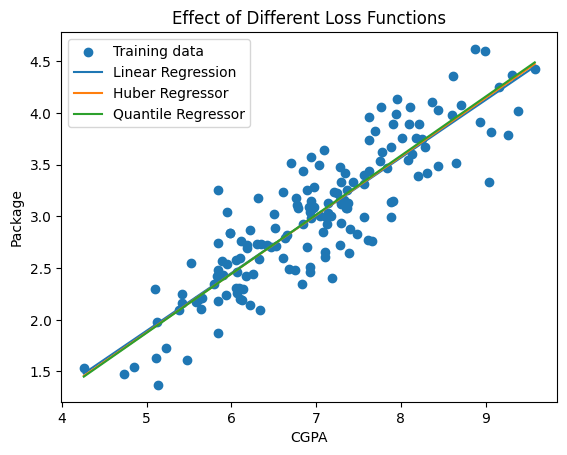

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Smooth CGPA values
X_range = np.linspace(
    X_train.min(),
    X_train.max(),
    100
).reshape(-1, 1)

# Predictions
y_lr = lr.predict(X_range)
y_hb = hb.predict(X_range)
y_qr = qr.predict(X_range)

# Plot data
plt.scatter(X_train, y_train, label="Training data")

# Plot fitted lines
plt.plot(X_range, y_lr, label="Linear Regression")
plt.plot(X_range, y_hb, label="Huber Regressor")
plt.plot(X_range, y_qr, label="Quantile Regressor")

plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("Effect of Different Loss Functions")
plt.legend()
plt.show()